# EPSP ratio comparison with Banerjee et al. 2014 dataset

In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display
from epsp_ratio_summary_common import *

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

# Load in vitro data
invitro = pd.read_csv('data/invitro/paired_recordings.csv')
invitro = invitro[invitro.reference == "Banerjee et al. 2014"]
invitro['std_epsp_ratio'] = invitro['sem_epsp_ratio'] * np.sqrt(invitro['sample_size'])
invitro

,protocol_id,pre_mtype,post_mtype,area,animal,age,frequency_train,dt_train,n_stimuli_train,n_sweep,period_sweep,mean_epsp_ratio,sem_epsp_ratio,sample_size,reference,notes,std_epsp_ratio
33,bnr14_01,L23PC,L23PC,SSC (barrel),mouse,P12 - P18,0.2,-15,1,100,5,0.77,0.07,5,Banerjee et al. 2014,Used EPSP slope for EPSP ratio estimation. Del...,0.156525
34,bnr14_02,L23PC,L23PC,SSC (barrel),mouse,P12 - P18,0.2,-15,1,100,5,0.80,0.06,6,Banerjee et al. 2014,MK-801 in PRESYNAPTIC pipette to block NMDA re...,0.146969


In [2]:
# Merge EPSP amplitude and EPSP slope datasets
df = pd.read_csv('data/insilico/banerjee_2014/L23PC_L23PC.csv')
df_slope = pd.read_csv('data/insilico/banerjee_2014/L23PC_L23PC_slope.csv')
df_merge = pd.merge(df_slope, df[["epsp_before", "epsp_after", "epsp_ratio"]],
                    left_index=True, right_index=True, suffixes=('', '_amplitude'))
df_merge.to_csv('data/insilico/banerjee_2014/L23PC_L23PC_merge.csv')

In [3]:
# Load Banerjee et al. 2014 data
insilico_exp, insilico_out, insilico = load_insilico('data/insilico/banerjee_2014/L23PC_L23PC_merge.csv', epsp_cut=0.05)

Found outliers in data/insilico/banerjee_2014/L23PC_L23PC_merge.csv:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before_amplitude
9,26424,26467,0.2,-15,16.075852,0.030695
29,5560,122410,0.2,-15,1.077682,0.033253


Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before_amplitude
65,17262,11754,0.2,-15,0.967447,0.623951
38,123068,126422,0.2,-15,1.250984,0.050301
56,26543,3590,0.2,-15,1.143664,0.736985
64,123715,17659,0.2,-15,0.331104,1.914643
80,3786,2275,0.2,-15,0.846385,0.685638


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,0.2,-15,0.96963,0.752867,0.076051,98


t-test results for frequency_train = 0.200000: s = 1.931, p = 0.069


Text(0.5, 1.0, '$\\Delta t$ = -15 ms')

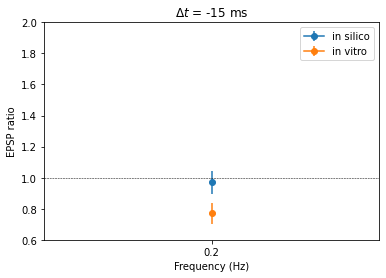

In [4]:
# Plot LTP freq
sel_invitro = invitro[invitro.protocol_id=='bnr14_01']
sel_insilico = insilico

fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', offset=False)

if pubstyle:
    fig.set_size_inches(0.8, 1.37795, forward=True)
ax.xaxis.set_major_locator(plt.FixedLocator([0.2]))
ax.legend()
ax.set_ylim(0.6, 2)
ax.set_title(r'$\Delta t$ = -15 ms')

#fig.savefig('l23_l23_ltd_bnr14.svg')

Model fit: 0.74 (+/- 0.03) x ^ -0.26 (+/- 0.08)


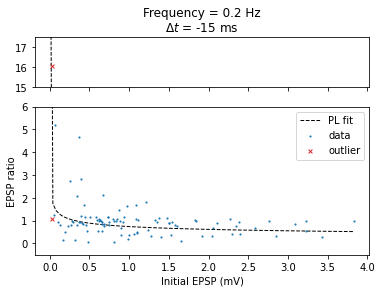

In [5]:
sel = pd.concat([insilico_exp, insilico_out])

popt, perr = fit_powerlaw(sel.epsp_before_amplitude, sel.epsp_ratio)
print('Model fit: %.2f (+/- %.2f) x ^ %.2f (+/- %.2f)' % (popt[0], perr[0], popt[1], perr[1]))
x = np.linspace(1e-6, np.max(insilico_exp.epsp_before_amplitude), 100)

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Plot data twice
def plot_data(ax):
    ax.scatter(insilico_exp.epsp_before_amplitude, insilico_exp.epsp_ratio, s=5, alpha=1, marker='.', c='C0', label='data')
    ax.scatter(insilico_out.epsp_before_amplitude, insilico_out.epsp_ratio, s=15, lw=1, alpha=1, marker='x', c='C3', label='outlier')
    ax.plot(x, powerlaw(x, *popt), lw=1, c='k', ls='dashed', label='PL fit', zorder=-1)
plot_data(ax_top)
plot_data(ax_bottom)

# Set appropriate axis limits
ax_top.set_ylim(15, 17.5)
ax_bottom.set_ylim(-0.5, 6)
assert insilico_exp.epsp_ratio.max() < 6
assert insilico_exp.epsp_ratio.min() > -0.5
assert insilico_out.epsp_ratio.max() < 17.5
assert insilico_out.epsp_ratio.min() > -0.5

# Finalize plot
ax_bottom.legend()
ax_top.set_title('Frequency = 0.2 Hz\n' + r'$\Delta t$ = -15 ms')
ax_bottom.set_ylabel('EPSP ratio')
ax_bottom.set_xlabel('Initial EPSP (mV)')
if pubstyle:
    ax_top.spines['bottom'].set_visible(False)
    fig.set_size_inches(1.16535, 1.37795, forward=True)

#fig.savefig('l23_l23_powerlaw_bnr14.svg')

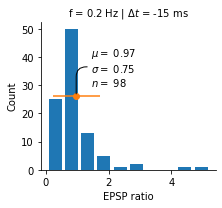

In [6]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity
insilico_plot = insilico_exp.rename(columns={"frequency_train": "f",
                                             "dt_train": "$\Delta t$",
                                             "epsp_ratio": "EPSP ratio"})

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

#g.savefig("l23_l23_bnr14_hist.png", dpi=300)